# Demo: 2D image RI2FL

> 2D RI2FL demo


In [7]:
#| default_exp demo

In [8]:
#| hide
from nbdev.showdoc import *

In [9]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from fastai.vision.all import *
from monai.utils import set_determinism
set_determinism(0)
# from sklearn.model_selection import train_test_split

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### Data

In [17]:
bs, size = 8, 128
# arch = models.resnet34
path = Path('../_data/Babesia')
path_x = path/'RI'
path_y = path/'TRITC'

In [18]:
from bioMONAI.core import get_target
get_target(path_y, same_filename=False, signal_file_prefix='RI', target_file_prefix='TRITC')(path / 'O11_RI_frame01.tiff')

Path('../_data/Babesia/TRITC/O11_TRITC_frame01.tiff')

### Look at training data

In [19]:
from monai.transforms import ScaleIntensity

item_tfms = [ScaleIntensity(minv=0.0, maxv=1.0),
             RandCropND(size), 
             RandRot90(prob=0.5), 
             RandFlip(prob=0.75),
             ] 

Setting-up type transforms pipelines
Found 275 items
2 datasets of sizes 220,55
Setting up Pipeline: BioImageProject.create
Setting up Pipeline: get_target.<locals>.generate_target_path -> BioImage.create

Building one sample
  Pipeline: BioImageProject.create
    starting from
      ../_data/Babesia/RI/Q11_RI_frame20.tiff
    applying BioImageProject.create gives
      BioImageProject of size 1x512x512
  Pipeline: get_target.<locals>.generate_target_path -> BioImage.create
    starting from
      ../_data/Babesia/RI/Q11_RI_frame20.tiff
    applying get_target.<locals>.generate_target_path gives
      ../_data/Babesia/TRITC/Q11_TRITC_frame20.tiff
    applying BioImage.create gives
      BioImage of size 1x512x512



Final sample: (BioImage([[[135., 135., 135.,  ..., 135., 135., 135.],
         [135., 135., 135.,  ..., 135., 135., 135.],
         [135., 135., 135.,  ..., 135., 135., 135.],
         ...,
         [135., 135., 135.,  ..., 135., 135., 135.],
         [135., 135., 135.,  ..., 135., 135., 135.],
         [135., 135., 135.,  ..., 135., 135., 135.]]]), BioImage([[[24., 24., 24.,  ..., 17., 18., 19.],
         [24., 23., 23.,  ..., 18., 19., 20.],
         [23., 23., 23.,  ..., 18., 19., 17.],
         ...,
         [24., 24., 24.,  ..., 20., 19., 20.],
         [25., 23., 23.,  ..., 21., 19., 20.],
         [23., 25., 24.,  ..., 19., 20., 19.]]]))


Found 275 items
2 datasets of sizes 220,55
Setting up Pipeline: BioImageProject.create
Setting up Pipeline: get_target.<locals>.generate_target_path -> BioImage.create
Setting up after_item: Pipeline: ScaleIntensity -> RandCropND -- {'size': (128, 128, 128), 'lazy': False, 'p': 1.0} -> RandRot90 -- {'prob': 0.5, 'max_k': 3, 'spatial_axes': (0

Setting affine, but the applied meta contains an affine. This will be overwritten.


  Pipeline: ScaleIntensity -> RandCropND -- {'size': (128, 128, 128), 'lazy': False, 'p': 1.0} -> RandRot90 -- {'prob': 0.5, 'max_k': 3, 'spatial_axes': (0, 1), 'ndim': 2, 'lazy': False, 'p': 1.0} -> RandFlip -- {'prob': 0.75, 'spatial_axis': None, 'ndim': 2, 'lazy': False, 'p': 1.0} -> ToTensor
    starting from
      (BioImageProject of size 1x512x512, BioImage of size 1x512x512)
    applying ScaleIntensity gives
      (MetaTensor of size 1x512x512, MetaTensor of size 1x512x512)
    applying RandCropND -- {'size': (128, 128, 128), 'lazy': False, 'p': 1.0} gives
      (MetaTensor of size 1x128x128, MetaTensor of size 1x128x128)
    applying RandRot90 -- {'prob': 0.5, 'max_k': 3, 'spatial_axes': (0, 1), 'ndim': 2, 'lazy': False, 'p': 1.0} gives
      (MetaTensor of size 1x128x128, MetaTensor of size 1x128x128)
    applying RandFlip -- {'prob': 0.75, 'spatial_axis': None, 'ndim': 2, 'lazy': False, 'p': 1.0} gives
      (MetaTensor of size 1x128x128, MetaTensor of size 1x128x128)
    app

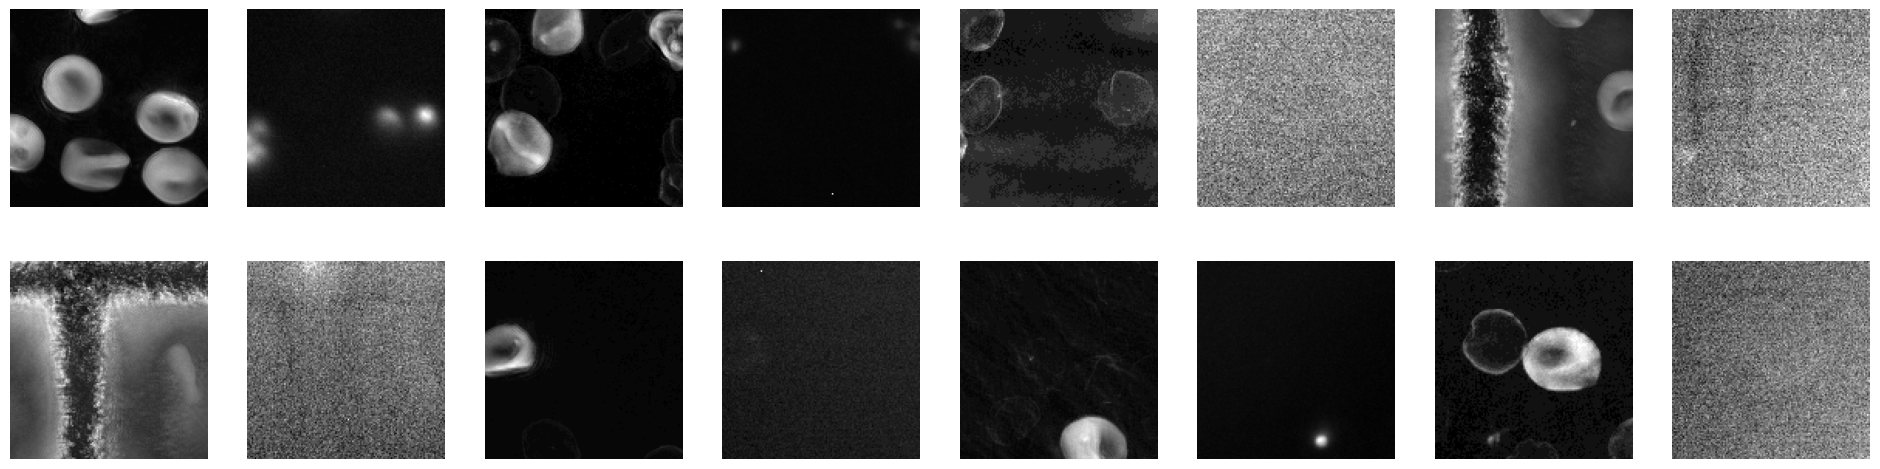

In [20]:
from bioMONAI.core import get_target

dblock = DataBlock(blocks=(BioImageBlock(cls=BioImageProject), BioImageBlock(cls=BioImage)),
                   get_items=get_image_files,
                   get_y=get_target(path_y, same_filename=False, signal_file_prefix='RI', target_file_prefix='TRITC'),
                   splitter=RandomSplitter(valid_pct=0.2),
                   item_tfms=item_tfms,
                   )

dblock.summary(path_x)

dls = dblock.dataloaders(path_x, bs=bs)
dls.show_batch(max_n=8, cmap='gray')


In [21]:
# training and validation
len(dls.train_ds.items), len(dls.valid_ds.items)

(220, 55)

### Create and train a 2D model

In [22]:
from monai.networks.nets import UNet # AttentionUnet, DynUNet, UNet, BasicUNet

In [23]:
# model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64, 128, 256),strides=(2, 2, 2, 2), num_res_units=2).model
model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(32, 64, 128, 256),strides=(1, 2, 2), num_res_units=2).model
# model = AttentionUnet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64),strides=(1, 1))
# model = DynUNet(spatial_dims=2, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True) # it tends to create hot pixels
# model = BasicUNet(spatial_dims=2, in_channels=1, out_channels=1)

In [24]:
from bioMONAI.losses import CombinedLoss
loss_func = mse #CombinedLoss()

In [25]:
from bioMONAI.losses import SSIMMetric

metrics = [mae, mse, SSIMMetric]

In [26]:
# learn = Learner(dls, model, loss_func=loss_func, opt_func=ranger, metrics=nn.L1Loss)
learn = Learner(dls, model, loss_func=loss_func, metrics=metrics, cbs=ShowGraphCallback())

In [27]:
learn.summary()

Sequential (Input shape: 8 x 1 x 128 x 128)
Layer (type)         Output Shape         Param #    Trainable 
                     8 x 32 x 128 x 128  
Conv2d                                    320        True      
InstanceNorm2d                            0          False     
Dropout                                                        
PReLU                                     1          True      
Conv2d                                    9248       True      
InstanceNorm2d                            0          False     
Dropout                                                        
PReLU                                     1          True      
Conv2d                                    64         True      
____________________________________________________________________________
                     8 x 64 x 64 x 64    
Conv2d                                    18496      True      
InstanceNorm2d                            0          False     
Dropout                    

SuggestedLRs(valley=0.0008317637839354575)


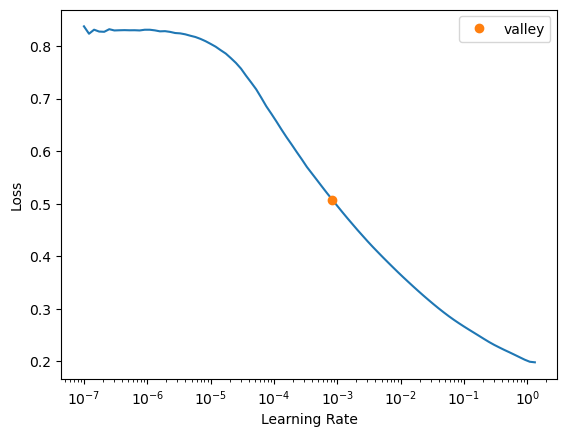

In [28]:
# lr = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))
lr = learn.lr_find(suggest_funcs=(valley))
print(lr)

In [29]:
lr = float('%.1g'%(lr))
print(lr)

0.0008


epoch,train_loss,valid_loss,mae,mse,SSIM,time
0,0.120595,0.047015,0.104415,0.047015,0.316532,00:17
1,0.067585,0.029601,0.058961,0.029601,0.521825,00:16
2,0.045258,0.020433,0.043554,0.020433,0.645719,00:16
3,0.031961,0.014162,0.032765,0.014162,0.724860,00:15
4,0.022944,0.009589,0.028866,0.009589,0.752201,00:16
5,0.016441,0.006319,0.025270,0.006319,0.768914,00:15
6,0.011637,0.003957,0.021822,0.003957,0.798886,00:15
7,0.008104,0.002487,0.020054,0.002487,0.801018,00:15
8,0.005638,0.001812,0.018775,0.001812,0.817240,00:15
9,0.004088,0.001712,0.018060,0.001712,0.822296,00:15


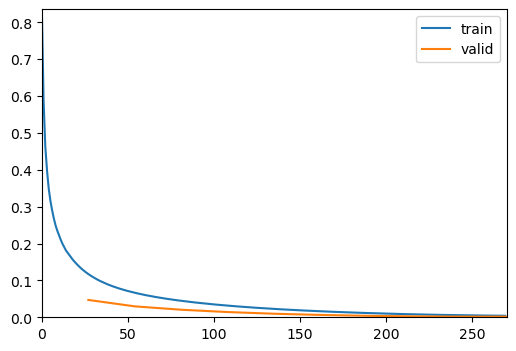

In [30]:
learn.fit_flat_cos(10,lr)

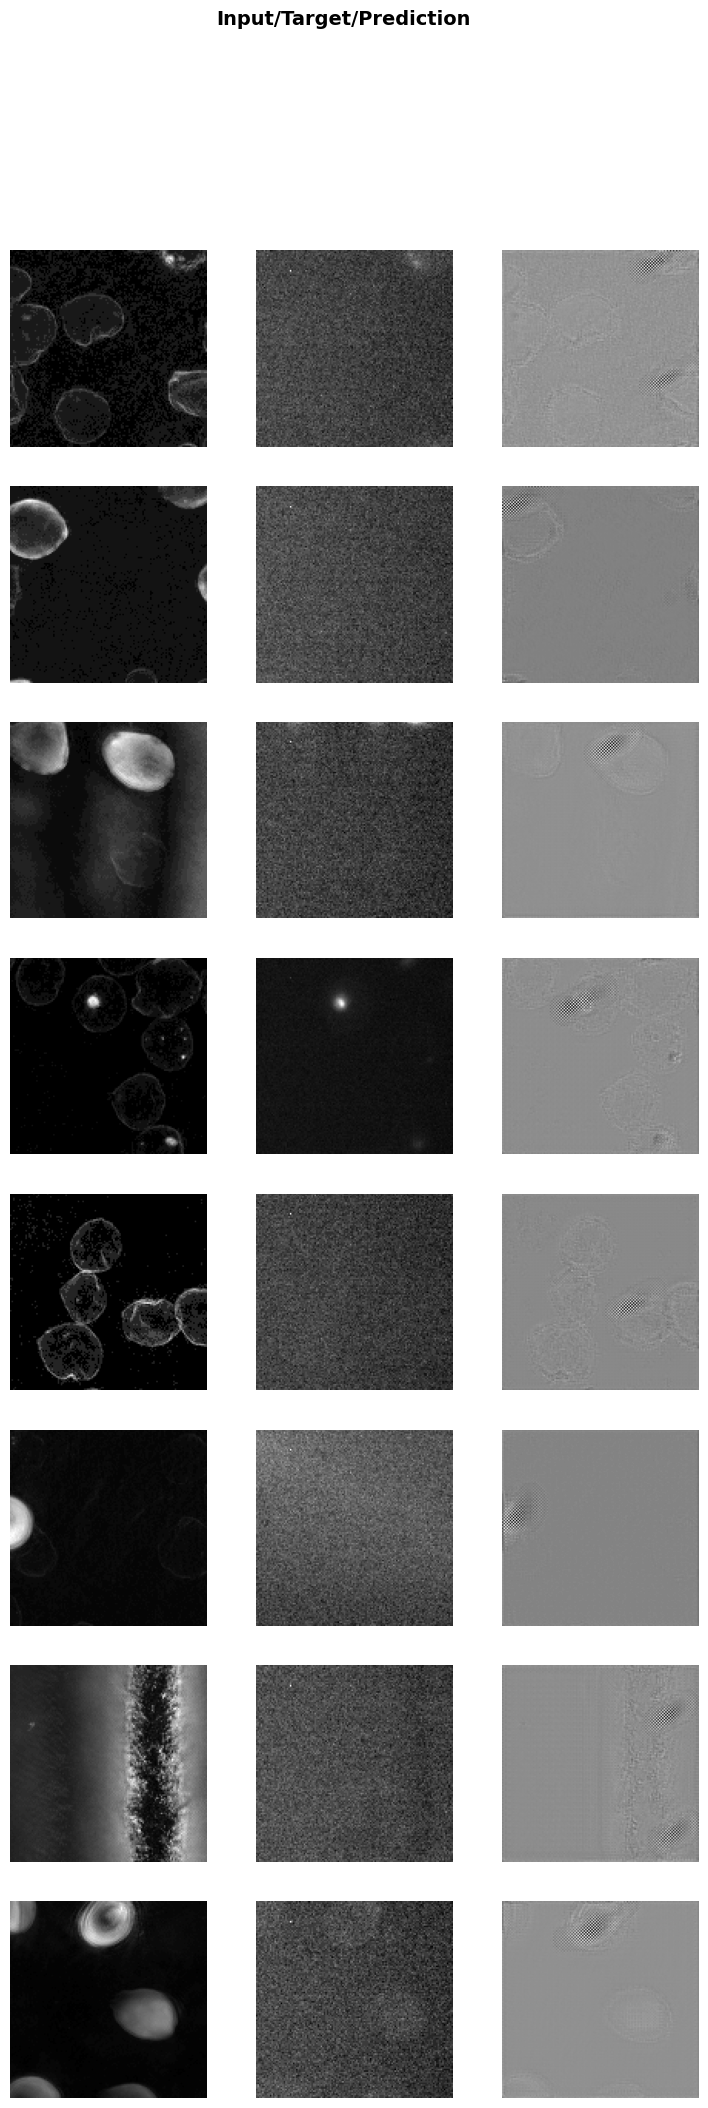

In [31]:
learn.show_results(cmap='gray')

In [32]:
# learn.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!

### Export learner

In [33]:
# store_variables(pkl_fn='vars.pkl', size=size, reorder=reorder,  resample=resample)

In [34]:
# learn.export('______.pkl')

In [35]:
#| hide
import nbdev; nbdev.nbdev_export()